In [2]:
#Our World in Data's CO2 dataset
import pandas as pd

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.columns.tolist())

(50411, 79)
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_p

In [3]:
# Select necessary columns
df = df[["country", "year", "iso_code", "population",
         "co2", "co2_per_capita", "share_global_co2",
         "cumulative_co2", "energy_per_capita"]]

# Check the data
print(df.shape)
df.head()

(50411, 9)


,country,year,iso_code,population,co2,co2_per_capita,share_global_co2,cumulative_co2,energy_per_capita
0,Afghanistan,1750,AFG,2802560.0,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Remove rows with no iso_code
df = df[df["iso_code"].notna()]

# Remove rows where co2 is missing
df = df[df["co2"].notna()]

# Check cleaned data
print(df.shape)
print(df["country"].nunique(), "unique countries")
print(df["year"].min(), "to", df["year"].max())

(23408, 9)
215 unique countries
1750 to 2024


In [5]:
#Question 1: Which countries emit the most CO2?
# Filter to 2023 (most recent complete year)
df_2023 = df[df["year"] == 2023]

# Top 10 emitters
top10 = df_2023.nlargest(10, "co2")[["country", "co2"]]
print(top10)

             country        co2
9932           China  12172.009
48006  United States   4918.407
21761          India   3062.756
38313         Russia   1733.135
23811          Japan    986.910
22661           Iran    789.676
21936      Indonesia    762.358
40288   Saudi Arabia    677.442
18318        Germany    593.766
43037    South Korea    589.178


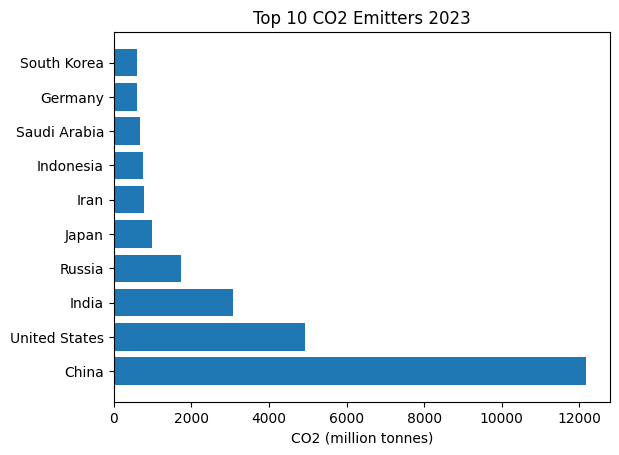

In [6]:
import matplotlib.pyplot as plt

plt.barh(top10["country"], top10["co2"])
plt.title("Top 10 CO2 Emitters 2023")
plt.xlabel("CO2 (million tonnes)")
plt.show()

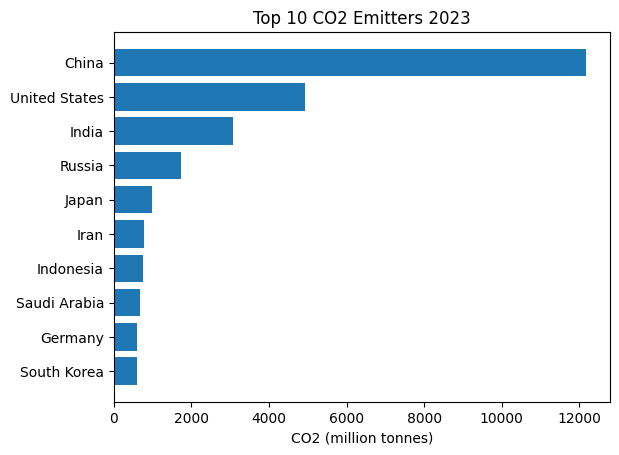

In [7]:
top10_sorted = top10.sort_values("co2")
plt.barh(top10_sorted["country"], top10_sorted["co2"])
plt.title("Top 10 CO2 Emitters 2023")
plt.xlabel("CO2 (million tonnes)")
plt.show()

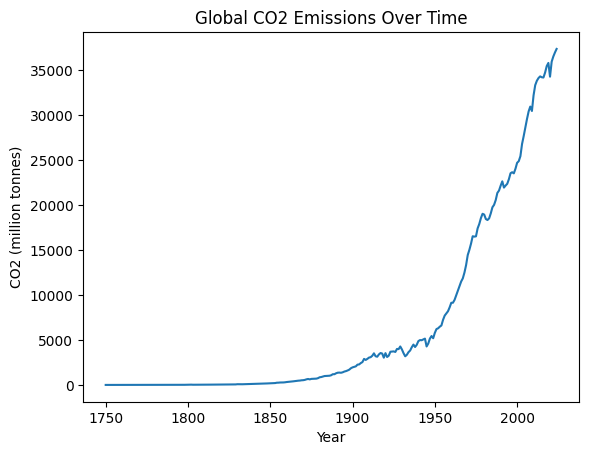

In [11]:
#Question 2: How have global CO2 emissions changed over time?
# Group by year and sum all countries' co2
global_co2 = df.groupby("year")["co2"].sum().reset_index()

# Plot it
plt.plot(global_co2["year"], global_co2["co2"])
plt.title("Global CO2 Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("CO2 (million tonnes)")
plt.show()

In [12]:
#Question 3 — which countries have the highest CO2 per capita?
# Top 10 by co2 per capita in 2023
top10_capita = df_2023.nlargest(10, "co2_per_capita")[["country", "co2_per_capita"]]
print(top10_capita)

                         country  co2_per_capita
37959                      Qatar          40.128
7661                      Brunei          27.241
24864                     Kuwait          25.454
4513                     Bahrain          24.710
45798        Trinidad and Tobago          23.644
40288               Saudi Arabia          20.365
47506       United Arab Emirates          19.773
32409              New Caledonia          17.483
41537  Sint Maarten (Dutch part)          16.157
35884                       Oman          15.806


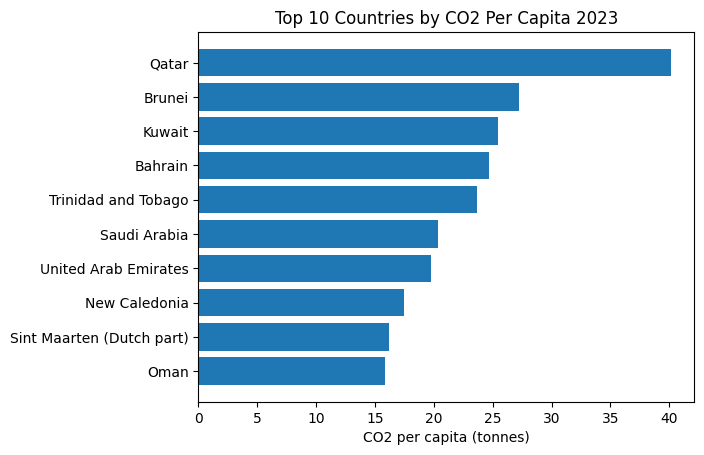

In [13]:
top10_capita_sorted = top10_capita.sort_values("co2_per_capita")

plt.barh(top10_capita_sorted["country"], top10_capita_sorted["co2_per_capita"])
plt.title("Top 10 Countries by CO2 Per Capita 2023")
plt.xlabel("CO2 per capita (tonnes)")
plt.show()

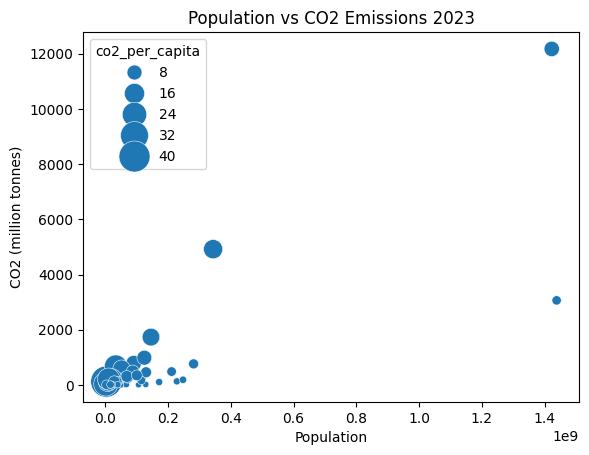

In [14]:
#Question 4 — how does population relate to emissions?
import seaborn as sns

# Filter out very small emitters for a cleaner chart
df_2023_clean = df_2023[df_2023["population"] > 1000000]

sns.scatterplot(data=df_2023_clean, x="population", y="co2", size="co2_per_capita", sizes=(20, 500))
plt.title("Population vs CO2 Emissions 2023")
plt.xlabel("Population")
plt.ylabel("CO2 (million tonnes)")
plt.show()

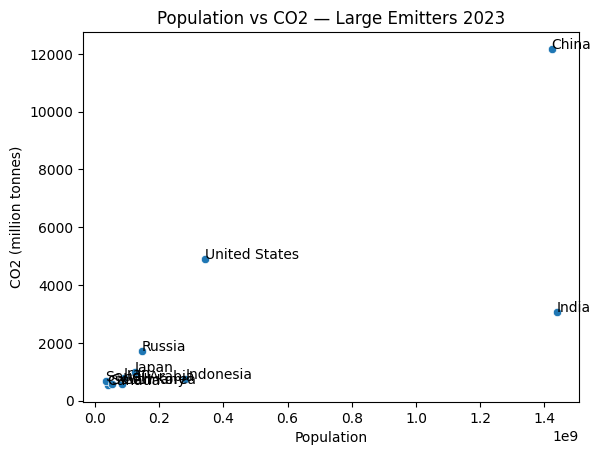

In [15]:
df_2023_clean = df_2023[df_2023["co2"] > 500]

fig, ax = plt.subplots()
sns.scatterplot(data=df_2023_clean, x="population", y="co2", ax=ax)

for idx, row in df_2023_clean.iterrows():
    ax.annotate(row["country"], (row["population"], row["co2"]))

plt.title("Population vs CO2 — Large Emitters 2023")
plt.xlabel("Population")
plt.ylabel("CO2 (million tonnes)")
plt.show()

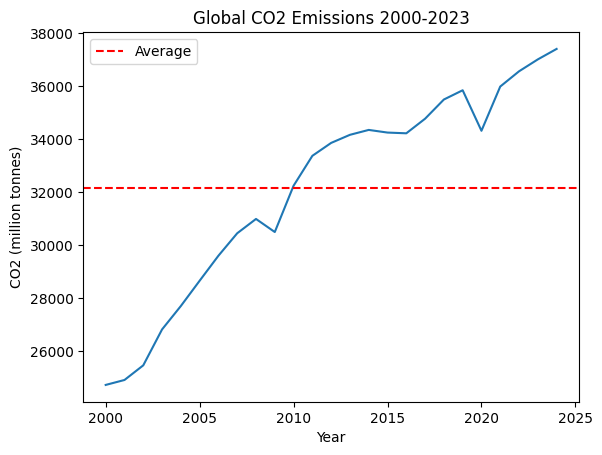

In [17]:
# Question 5 — are emissions rising or falling in recent years?
# Filter to recent years 2000-2023
recent = global_co2[global_co2["year"] >= 2000]

plt.plot(recent["year"], recent["co2"])
plt.title("Global CO2 Emissions 2000-2023")
plt.xlabel("Year")
plt.ylabel("CO2 (million tonnes)")
plt.axhline(recent["co2"].mean(), color="red", linestyle="--", label="Average")
plt.legend()
plt.show()